## Construye tu clasificador de imágenes a color
En este ejercicio propondrás una red convolucional diferente a la utilizada en la explicación del material M6.3 para clasificar Cifar 10.
Tu objetivo será alcanzar un desempeño similar a ~75% de exactitud (accuracy) al clasificar con datos de validación (test).
Podrás basarte en el modelo descrito en M6.3 y cambiar los hiperparámetros: añadir o quitar capas de convolucionales, pooling o dense. Tambien puedes variar el tamaño y número de kernels o filtros, etc.
Recuerda que las clases son las siguientes:
- 0 -> aviones
- 1 -> automóviles
- 2 -> aves
- 3 -> gatos
- 4 -> venados
- 5 -> perros
- 6 -> ranas
- 7 -> caballos
- 8 -> barcos
- 9 -> tractocamiones

In [ ]:
# Define una semilla para los números aleatorios
from numpy.random import seed
seed(1)

In [ ]:
# Importa las librerías
import matplotlib.pyplot as plt                 # Librería para graficar
import numpy as np                              # Librería para cálculos matemáticos

# Importa las funciones de keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras import optimizers, backend
import tensorflow.keras.utils as image_utils
from tensorflow.keras.datasets import cifar10   # Función para descargar las imágenes de Cifar 10
from tensorflow.keras.callbacks import ModelCheckpoint # Clase para guardar los pesos sinápticos de los modelos neuronales

In [ ]:
# Obtención de las imágenes y sus etiquetas
# La función load_data() da como respuesta los grupos de entrenamiento y test por separado
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Imprimimos el tamaño de los conjuntos de entrenamiento y prueba
print('El numero de imágenes en el conjunto x_train es:', x_train.shape[0])
print('El numero de etiquetas en el conjunto y_train es:', y_train.shape[0])
print('El numero de imágenes en el conjunto x_test es:', x_test.shape[0])
print('El numero de etiquetas en el conjunto y_test es:', y_test.shape[0])

El numero de imágenes en el conjunto x_train es: 50000
El numero de etiquetas en el conjunto y_train es: 50000
El numero de imágenes en el conjunto x_test es: 10000
El numero de etiquetas en el conjunto y_test es: 10000


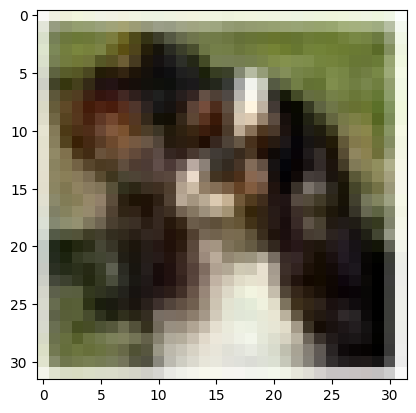

La imagen de entrenamiento 500, corresponde con la etiqueta: [5]


In [ ]:
# Inspección visual de los datos

# EJERCICIO
# Grafica algunas imágenes del dataset y checa sus etiquetas
n_imagen = 500
etiqueta = y_train[n_imagen]
plt.imshow(x_train[n_imagen], cmap='Accent')
plt.show()
print('La imagen de entrenamiento {}, corresponde con la etiqueta: {}'.format(n_imagen, etiqueta))

## Preprocesamiento de los datos
Cuando se entrenan redes neuronales convolucionales no es necesario aplanar las imágenes en un vector, se usan con su formato matricial y numero de canales 3 (RGB).  
Sin embargo, es recomendable escalar los valores de los pixeles de 0-255 a 0-1.
También es necesario convertir a codificación 1-hot las etiquetas. Con 1-hot pasamos de tener una etiqueta que representa la clase 4 a un vector de 10 elementos donde el 4° elemento sea un 1 (comenzando desde la posición 0)
etiqueta 4 -> 0000100000

In [ ]:
# EJERCICIO
# Escala los valores de los pixeles para que esten en el rango de 0 a 1
x_train = x_train/255
x_test = x_test/255

In [ ]:
# EJERCICIO
# Aplica codificación 1-hot de las etiquetas
y_train_1h = image_utils.to_categorical(y_train)
y_test_1h = image_utils.to_categorical(y_test)

# Visualiza la etiqueta 100 codificada
print(y_train[100], ' -> ', y_train_1h[100])

[8]  ->  [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


## Creación del modelo

Gran parte del trabajo para construir modelos de Deep Learning se centra en la experimentación.
Propon un modelo, entrénalo y cambia los hiperparámetros. Analiza los resultados. ¿Qué puedes concluir?

In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
# EJERCICIO
# Escribe la línea de código que elimina información previa de los modelos
backend.clear_session()

In [ ]:
# EJERCICIO
# Define tu modelo
modeloConv = Sequential()
modeloConv.add(Input(shape = (32,32,3)))
modeloConv.add(Conv2D(32, kernel_size = (3,3), activation = 'relu'))
modeloConv.add(MaxPooling2D(pool_size = (2,2)))
modeloConv.add(Conv2D(64, kernel_size = (3,3), activation = 'relu'))
modeloConv.add(MaxPooling2D(pool_size = (2,2)))
modeloConv.add(Conv2D(128, kernel_size = (3,3), activation = 'relu'))
modeloConv.add(Dropout(0.3))
modeloConv.add(MaxPooling2D(pool_size = (2,2)))
modeloConv.add(Conv2D(256, kernel_size = (2,2), activation = 'relu'))
modeloConv.add(Flatten())
modeloConv.add(Dense(70, activation = 'relu'))
modeloConv.add(Dropout(0.4))
modeloConv.add(Dense(10, activation = 'softmax'))

In [ ]:
# EJERCICIO
# Muestra la tabla con las características de tu modelo
modeloConv.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 1, 256)      │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 70)             │        17,990 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,276 (950.30 KB)

 Trainable params: 243,276 (950.30 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del modelo

In [ ]:
# EJERCICIO
# Define del optimizador Adam
adam = optimizers.Adam(learning_rate = 0.001)

# EJERCICIO
# Compila el modelo
modeloConv.compile(optimizer = adam,
                   loss = 'categorical_crossentropy',
                   metrics = ['accuracy'])

In [ ]:
# Define un checkpointer para guardar los pesos sinapticos de la red
checkpointer = ModelCheckpoint('modelo_v1.keras', monitor='val_accuracy',
                               save_best_only=True, mode='max', verbose=1)

In [ ]:
# Entrena tu modelo, recuerda utilizar las etiquetas generadas por la codificación 1-hot (y_train1, y_test1)
M = modeloConv.fit(x_train, y_train_1h,
                   validation_data = (x_test, y_test_1h),
                   epochs = 20,
                   callbacks = [checkpointer],
                   verbose = True)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3027 - loss: 1.8654
Epoch 1: val_accuracy improved from -inf to 0.50050, saving model to modelo_v1.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3028 - loss: 1.8652 - val_accuracy: 0.5005 - val_loss: 1.4594
Epoch 2/20
1552/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5358 - loss: 1.3001
Epoch 2: val_accuracy improved from 0.50050 to 0.60070, saving model to modelo_v1.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5360 - loss: 1.2997 - val_accuracy: 0.6007 - val_loss: 1.1421
Epoch 3/20
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6126 - loss: 1.1084
Epoch 3: val_accuracy improved from 0.60070 to 0.64940, saving model to modelo_v1.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6126 - loss: 1.1084 - val_accuracy: 0.6494 - val_loss: 1.0181
Epoch 4/20
1554/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6584 - loss: 0.9855
Epoch 4: val_accuracy improve

## Evaluación del modelo

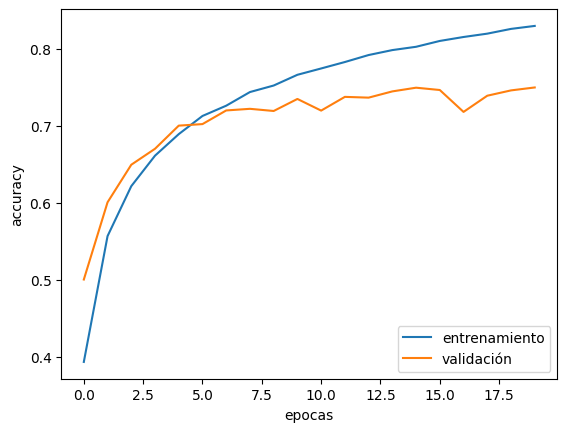

In [ ]:
# EJERCICIO
# Grafica el accuracy (exactitud) con datos de entrenamiento y validación
plt.plot(M.history['accuracy'], label='entrenamiento')
plt.plot(M.history['val_accuracy'], label='validación')
plt.legend(loc='lower right')
plt.xlabel('epocas')
plt.ylabel('accuracy')
plt.show()

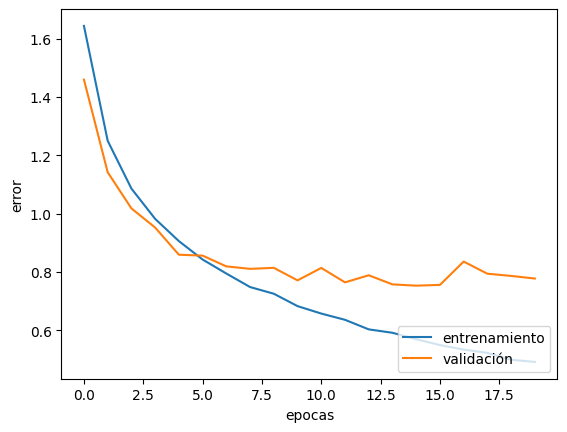

In [ ]:
# EJERCICIO
# Grafica el error (loss) con datos de entrenamiento y validación
plt.plot(M.history['loss'], label='entrenamiento')
plt.plot(M.history['val_loss'], label='validación')
plt.legend(loc='lower right')
plt.xlabel('epocas')
plt.ylabel('error')
plt.show()

In [ ]:
# Cargando la mejor versión del modelo
modeloConv.load_weights('modelo_v1.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


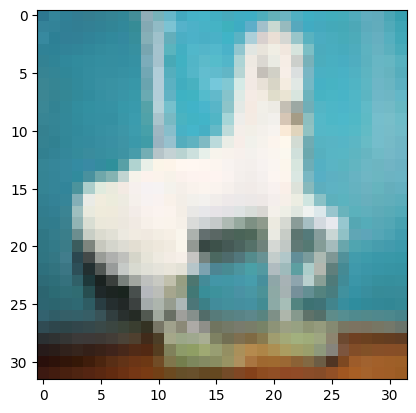

La imagen 1100, tiene la etiqueta [7], el modelo lo clasifica como: 0


In [ ]:
# EJERCICIO
# Realiza algunas clasificaciones con las imágenes de test
n_imagen = 1100
imagen = x_test[n_imagen]
etiqueta = y_test[n_imagen]
prediccion = np.argmax(modeloConv.predict(imagen.reshape(1,32,32,3)))

# Gráfica de la imagen
plt.imshow(imagen)
plt.show()
print('La imagen {}, tiene la etiqueta {}, el modelo lo clasifica como: {}'.format(n_imagen, etiqueta, prediccion))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


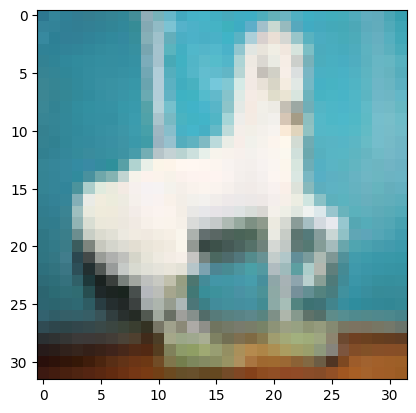

La imagen 1100, tiene la etiqueta [7], el modelo lo clasifica con indice: 0 - nombre: aviones


In [ ]:
tipos = {
    0: "aviones",
    1: "automóviles",
    2: "aves",
    3: "gatos",
    4: "venados",
    5: "perros",
    6: "ranas",
    7: "caballos",
    8: "barcos",
    9: "tractocamiones"
}

# EJERCICIO
# Realiza algunas clasificaciones con las imágenes de test
n_imagen = 1100
imagen = x_test[n_imagen]
etiqueta = y_test[n_imagen]
prediccion = np.argmax(modeloConv.predict(imagen.reshape(1,32,32,3)))
# Gráfica de la imagen
plt.imshow(imagen)
plt.show()
print('La imagen {}, tiene la etiqueta {}, el modelo lo clasifica con indice: {} - nombre: {}'.format(n_imagen, etiqueta, prediccion, tipos[prediccion]))